In [16]:
pip install opencv-contrib-python

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


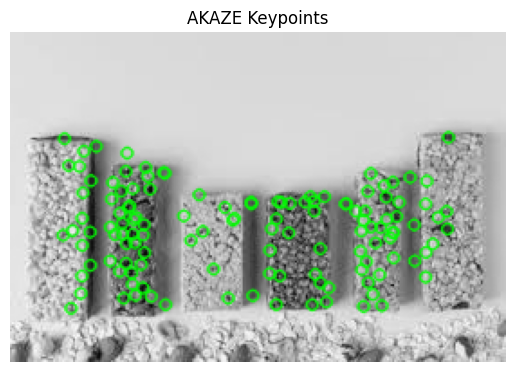

In [17]:
import cv2
import matplotlib.pyplot as plt

# Cargar la imagen
img = cv2.imread('barritas.png', cv2.IMREAD_GRAYSCALE)

# Crear un detector AKAZE
akaze = cv2.AKAZE_create()

# Detectar puntos clave y calcular descriptores
keypoints, descriptors = akaze.detectAndCompute(img, None)

# Dibujar los puntos clave
img_keypoints = cv2.drawKeypoints(img, keypoints, None, color=(0, 255, 0))

# Mostrar la imagen con los puntos clave
# cv2.imshow('AKAZE Keypoints', img_keypoints)
# cv2.waitKey(0)
# cv2.destroyAllWindows()

plt.imshow(img_keypoints)
plt.title("AKAZE Keypoints")
plt.axis('off')  # Ocultar los ejes
plt.show()

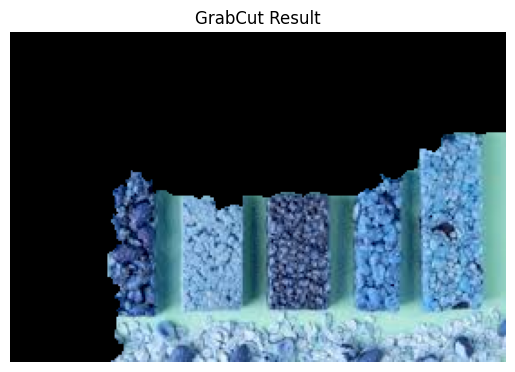

In [18]:
import cv2
import numpy as np

# Cargar la imagen (corregir el nombre del archivo)
img = cv2.imread('barritas.png')

# Crear una máscara para el algoritmo GrabCut
mask = np.zeros(img.shape[:2], np.uint8)

# Definir un rectángulo inicial para la segmentación
rect = (50, 50, 450, 290)

# Aplicar GrabCut
bgd_model = np.zeros((1, 65), np.float64)
fgd_model = np.zeros((1, 65), np.float64)

cv2.grabCut(img, mask, rect, bgd_model, fgd_model, 5, cv2.GC_INIT_WITH_RECT)

# Modificar la máscara para mostrar solo los objetos segmentados
mask2 = np.where((mask == 2) | (mask == 0), 0, 1).astype('uint8')
result = img * mask2[:, :, np.newaxis]

# Mostrar la imagen segmentada
# cv2.imshow('GrabCut Result', result)
# cv2.waitKey(0)
# cv2.destroyAllWindows()

plt.title('GrabCut Result')
plt.imshow(result, cmap=None)
plt.axis('off')

plt.show()


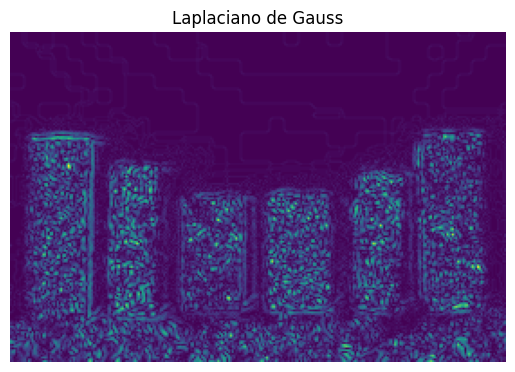

In [19]:
import cv2
import numpy as np

# Cargar la imagen
img = cv2.imread('barritas.png', cv2.IMREAD_GRAYSCALE)

# Aplicar un filtro Gaussiano para suavizar la imagen
blurred = cv2.GaussianBlur(img, (5, 5), 0)

# Aplicar el Laplaciano de Gauss
laplacian = cv2.Laplacian(blurred, cv2.CV_64F)

# Convertir a escala de grises y mostrar el resultado
laplacian = np.uint8(np.absolute(laplacian))

# Mostrar la imagen resultante
# cv2.imshow('Laplaciano de Gauss', laplacian)
# cv2.waitKey(0)
# cv2.destroyAllWindows()

plt.title('Laplaciano de Gauss')
plt.imshow(laplacian, cmap=None)
plt.axis('off')

plt.show()


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-64770.004..255.00002].


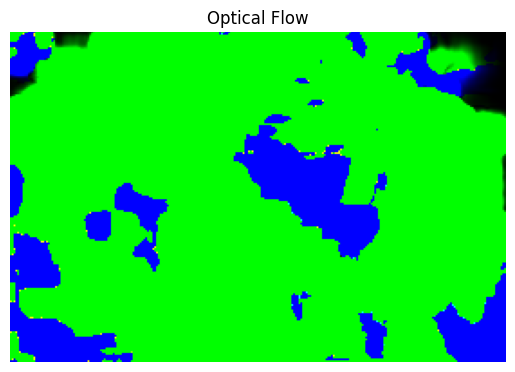

In [20]:
import cv2
import numpy as np

# Cargar dos imágenes consecutivas de un video
frame1 = cv2.imread('barritas.png', cv2.IMREAD_GRAYSCALE)
frame2 = cv2.imread('cereal.png', cv2.IMREAD_GRAYSCALE)

# Redimensionar frame2 para que coincida con frame1
if frame1.shape != frame2.shape:
	frame2 = cv2.resize(frame2, (frame1.shape[1], frame1.shape[0]))

# Calcular el flujo óptico usando el método de Lucas-Kanade
flow = cv2.calcOpticalFlowFarneback(frame1, frame2, None, 0.5, 3, 15, 3, 5, 1.2, 0)

# Convertir el flujo óptico a un formato visualizable
mag, ang = cv2.cartToPolar(flow[..., 0], flow[..., 1])
hsv = np.zeros_like(frame1, dtype=np.float32)
# Apilar imágenes en escala de grises para tener 3 canales
hsv = np.stack((hsv,hsv,hsv), axis=-1)
hsv[..., 1] = 255
hsv[..., 0] = ang * 180 / np.pi / 2
hsv[..., 2] = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX)
flow_rgb = cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)

# Mostrar el flujo óptico
# cv2.imshow('Optical Flow', flow_rgb)
# cv2.waitKey(0)
# cv2.destroyAllWindows()

plt.title('Optical Flow')
plt.imshow(flow_rgb, cmap=None)
plt.axis('off')

plt.show()
